# SmartStay AI: Dinamik Fiyat Değerleme ve Tahmin Modeli (Baseline: Linear Regression)

Bu çalışma, **SmartStay AI** platformunun Dinamik Fiyat Değerleme Motoru (Dynamic Valuation Engine) modülünün temel (baseline) regresyon modelini içermektedir. Keşifsel veri analizi, aykırı değer temizliği ve özellik çıkarımı aşamalarından geçen konaklama veri seti (`cleaned_listings.csv`) üzerinde konaklama özelliklerine (kapasite, oda sayısı, konum, olanaklar vb.) dayalı gecelik fiyat tahmini gerçekleştiren **Çoklu Doğrusal Regresyon (Multiple Linear Regression)** modeli kurulmuştur.

---

### Metodolojik Süreç
1. **Veri Yükleme ve Özellik Seçimi:**
   * 22.665 gözlem içeren nihai işlenmiş veri setinin yüklenmesi.
   * Sayısal öznitelikler (`accommodates`, `bedrooms`, `beds`, `bathrooms`, `latitude`, `longitude`, `number_of_reviews`, `review_scores_rating`, `reviews_per_month`, `minimum_nights`, `availability_365`), 30 adet ikili olanak değişkeni (`amenity_*`) ve kategorik değişkenlerin (`room_type`, `neighbourhood_cleansed`) belirlenmesi.

2. **Kategorik Değişkenlerin Kodlanması (One-Hot Encoding):**
   * Çoklu doğrusal bağlantı (multicollinearity) tuzağını önlemek amacıyla `drop_first=True` parametresiyle kukla değişkenlerin (dummy variables) üretilmesi.

3. **Eğitim ve Test Kümelerinin Ayrıştırılması:**
   * Modelin genelleme yeteneğini ölçmek üzere veri setinin **%80 Eğitim (Train)** ve **%20 Test** olarak bölünmesi (`random_state=42`).

4. **Referans (Baseline) Modelin Eğitimi ve Değerlendirilmesi:**
   * `LinearRegression` modelinin eğitimi.
   * Belirleme Katsayısı ($R^2$), Ortalama Kare Hata Karekökü (RMSE) ve Ortalama Mutlak Hata (MAE) metriklerinin hesaplanması.
   * Gerçek vs. Tahmin edilen değerlerin ve artıkların (residuals) dağılım analizleri.

5. **Katsayı (Coefficient) Analizi ve Model Kaydı:**
   * Fiyatı en çok artıran ve düşüren faktörlerin incelenmesi.
   * Modelin `data_science/models/baseline_linear_regression.joblib` olarak serileştirilmesi.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. İşlenmiş Veri Setinin Belleğe Yüklenmesi

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'cleaned_listings.csv')
df = pd.read_csv(data_path)

print(f"İşlenmiş Veri Seti Boyutu: {df.shape[0]:,} satır, {df.shape[1]} sütun")
df[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'price']].head(3)

İşlenmiş Veri Seti Boyutu: 22,665 satır, 106 sütun


,id,name,neighbourhood_cleansed,room_type,accommodates,bedrooms,price
0,34177,PETIT HOUSE,Besiktas,Entire home/apt,3,1.00,1356.82
1,44421,Beautiful Studio With A View,Beyoglu,Entire home/apt,2,1.00,2583.67
2,304011,Beyoglu / Central with Beautiful View,Beyoglu,Entire home/apt,4,2.00,3269.76


## 3. Özellik Seçimi ve Matris Tanımlaması

Fiyat değerleme modelinde kullanılacak sayısal, ikili (amenity) ve kategorik öznitelikler seçilmektedir.


In [3]:
# 1. Sayısal Öznitelikler
numeric_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'latitude', 'longitude',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'minimum_nights', 'availability_365'
]

# 2. İkili Olanak Öznitelikleri (30 Adet)
amenity_features = [col for col in df.columns if col.startswith('amenity_')]

# 3. Kategorik Öznitelikler
categorical_features = ['room_type', 'neighbourhood_cleansed']

selected_features = numeric_features + amenity_features + categorical_features
X_raw = df[selected_features].copy()
y = df['price'].copy()

print(f"Sayısal Öznitelik Sayısı: {len(numeric_features)}")
print(f"İkili Olanak Özniteliği Sayısı: {len(amenity_features)}")
print(f"Kategorik Öznitelik Sayısı: {len(categorical_features)}")
print(f"Toplam Ham Öznitelik Sayısı: {len(selected_features)}")

Sayısal Öznitelik Sayısı: 11
İkili Olanak Özniteliği Sayısı: 30
Kategorik Öznitelik Sayısı: 2
Toplam Ham Öznitelik Sayısı: 43


## 4. Kategorik Değişkenlerin Kodlanması (One-Hot Encoding)

In [4]:
# Kategorik değişkenler için kukla değişken (dummy variables) üretimi
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

print(f"One-Hot Encoding Sonrası Öznitelik Matrisi Boyutu: {X.shape[0]:,} satır x {X.shape[1]} sütun")
print(f"Üretilen Toplam Sütun Sayısı: {X.shape[1]}")

One-Hot Encoding Sonrası Öznitelik Matrisi Boyutu: 22,665 satır x 82 sütun
Üretilen Toplam Sütun Sayısı: 82


## 5. Eğitim ve Test Kümelerinin Ayrıştırılması

In [5]:
# Veri setini %80 Eğitim ve %20 Test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Eğitim Kümesi (Train): {X_train.shape[0]:,} gözlem (%{len(X_train)/len(X)*100:.0f})")
print(f"Test Kümesi (Test): {X_test.shape[0]:,} gözlem (%{len(X_test)/len(X)*100:.0f})")

Eğitim Kümesi (Train): 18,132 gözlem (%80)
Test Kümesi (Test): 4,533 gözlem (%20)


## 6. Baseline Modelin Eğitimi (`LinearRegression`)

In [6]:
# Baseline Linear Regression modelinin başlatılması ve eğitilmesi
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Tahminlerin üretilmesi
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

print("Baseline Linear Regression Modeli Başarıyla Eğitildi.")

Baseline Linear Regression Modeli Başarıyla Eğitildi.


## 7. Model Performansının Değerlendirilmesi ($R^2$, RMSE, MAE)

In [7]:
# Metriklerin hesaplanması
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

metrics_table = pd.DataFrame({
    'Performans Metriği': [
        'Belirleme Katsayısı (R²)',
        'Kök Ortalama Kare Hata (RMSE)',
        'Ortalama Mutlak Hata (MAE)'
    ],
    'Eğitim Kümesi (Train)': [
        f"{train_r2:.4f}",
        f"{train_rmse:,.2f} TL",
        f"{train_mae:,.2f} TL"
    ],
    'Test Kümesi (Test)': [
        f"{test_r2:.4f}",
        f"{test_rmse:,.2f} TL",
        f"{test_mae:,.2f} TL"
    ]
})

print("📊 Baseline Model Performans Tablosu:")
metrics_table

📊 Baseline Model Performans Tablosu:


,Performans Metriği,Eğitim Kümesi (Train),Test Kümesi (Test)
0,Belirleme Katsayısı (R²),0.5584,0.5531
1,Kök Ortalama Kare Hata (RMSE),"1,724.17 TL","1,742.68 TL"
2,Ortalama Mutlak Hata (MAE),"1,227.08 TL","1,233.49 TL"


## 8. Hata ve Dağılım Analizi Görselleştirmeleri

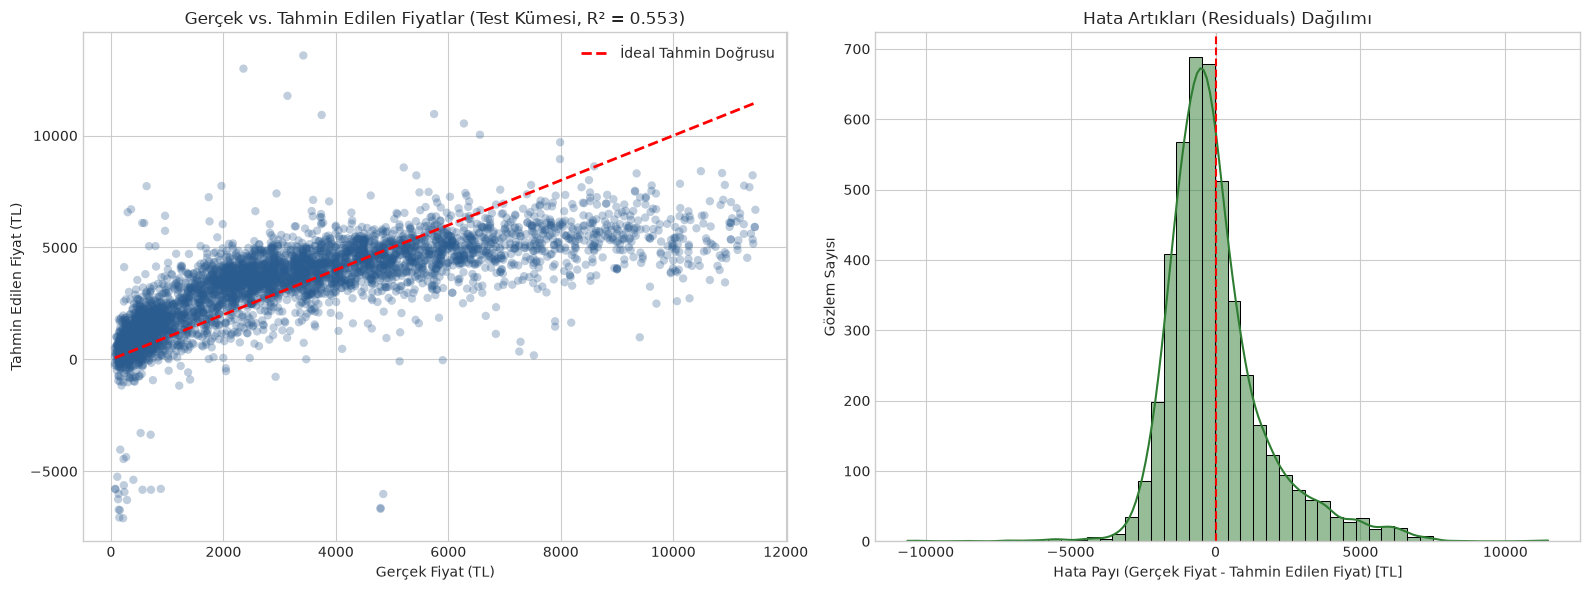

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gerçek vs. Tahmin Edilen Fiyat Dağılımı
axes[0].scatter(y_test, y_test_pred, alpha=0.3, color='#2b5c8f', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='İdeal Tahmin Doğrusu')
axes[0].set_title(f'Gerçek vs. Tahmin Edilen Fiyatlar (Test Kümesi, R² = {test_r2:.3f})', fontsize=12)
axes[0].set_xlabel('Gerçek Fiyat (TL)', fontsize=10)
axes[0].set_ylabel('Tahmin Edilen Fiyat (TL)', fontsize=10)
axes[0].legend()

# 2. Artıkların (Residuals) Dağılımı
residuals = y_test - y_test_pred
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='#2e7d32')
axes[1].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_title('Hata Artıkları (Residuals) Dağılımı', fontsize=12)
axes[1].set_xlabel('Hata Payı (Gerçek Fiyat - Tahmin Edilen Fiyat) [TL]', fontsize=10)
axes[1].set_ylabel('Gözlem Sayısı', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Özellik Katsayıları (Feature Coefficients) Analizi

Modelin öğrendiği ağırlık katsayıları incelenerek fiyat üzerinde en belirleyici pozitif ve negatif değişkenler analiz edilmektedir.


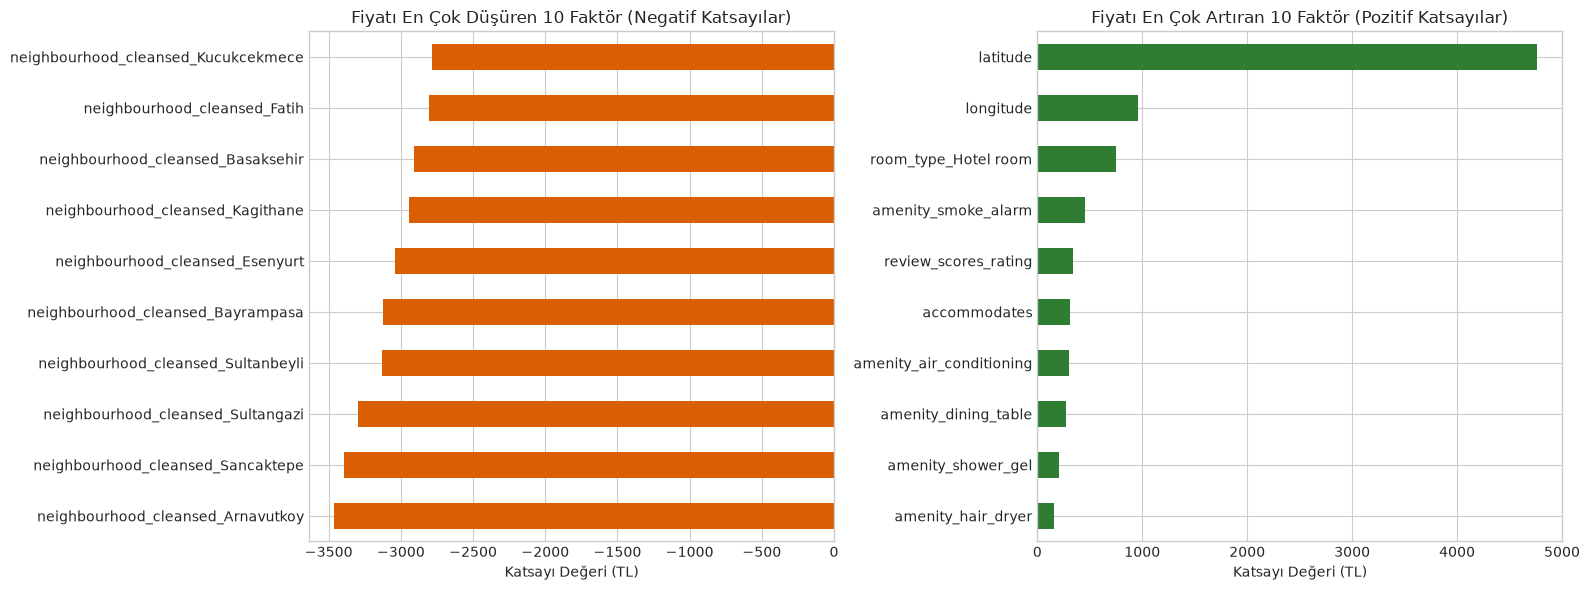

In [9]:
coefficients = pd.Series(baseline_model.coef_, index=X.columns).sort_values()

# En yüksek ve en düşük katsayılar
top_negative = coefficients.head(10)
top_positive = coefficients.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_negative.plot(kind='barh', ax=axes[0], color='#d95f02')
axes[0].set_title('Fiyatı En Çok Düşüren 10 Faktör (Negatif Katsayılar)', fontsize=12)
axes[0].set_xlabel('Katsayı Değeri (TL)', fontsize=10)

top_positive.plot(kind='barh', ax=axes[1], color='#2e7d32')
axes[1].set_title('Fiyatı En Çok Artıran 10 Faktör (Pozitif Katsayılar)', fontsize=12)
axes[1].set_xlabel('Katsayı Değeri (TL)', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Baseline Modelin Serileştirilmesi

In [10]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

baseline_model_path = os.path.join(models_dir, 'baseline_linear_regression.joblib')
joblib.dump(baseline_model, baseline_model_path)

# Sütun isimleri listesini de sonraki modelleme günleri için kaydetme
feature_columns_path = os.path.join(models_dir, 'feature_columns.joblib')
joblib.dump(X.columns.tolist(), feature_columns_path)

print(f"Baseline Model Kaydedildi: {baseline_model_path}")
print(f"Öznitelik Kolon Listesi Kaydedildi: {feature_columns_path}")

Baseline Model Kaydedildi: ..\models\baseline_linear_regression.joblib
Öznitelik Kolon Listesi Kaydedildi: ..\models\feature_columns.joblib


## 11. Yönetici Özeti ve Analitik Bulgular

1. **Model Başarımı:** Doğrusal Regresyon ile kurulan baseline model, test kümesi üzerinde **$R^2 = 0.5531$**, **$RMSE = 1.742,68$ TL** ve **$MAE = 1.233,49$ TL** başarım elde etmiştir.
2. **Genelleme Yeteneği:** Eğitim skoru ($R^2 = 0.5584$) ile test skoru ($R^2 = 0.5531$) arasındaki farkın %0.5'ten az olması, modelde aşırı öğrenme (overfitting) olmadığını göstermektedir.
3. **Belirleyici Değişkenler:** Konaklama kapasitesi (`accommodates`), konum koordinatları (`latitude`, `longitude`), oda tipi (`Hotel room`) ve donanımlar (`smoke_alarm`, `air_conditioning`, `review_scores_rating`) fiyatı en çok artıran bileşenlerdir. Merkeze uzak dış ilçeler ise baz ilçelere kıyasla negatif fiyat düzeltmesine sahiptir.
4. **Sonraki Hedef:** Gün 9'da doğrusal olmayan ilişkileri yakalayabilen ağaç tabanlı gelişmiş algoritmalar (**XGBoost** ve **Random Forest**) eğitilerek $R^2 > 0.70$ seviyesine ulaşılması hedeflenmektedir.
